# Anomaly Detection — Static Threshold vs Isolation Forest

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

## Load data

In [2]:
data = pd.read_csv('../data/labeled.csv', parse_dates=['timestamp'])
print('Total rows:', len(data))
print('Anomalies:', data['label'].sum())

Total rows: 16992
Anomalies: 250


## Split into training and test data (80% / 20%)

In [3]:
split_point = int(len(data) * 0.8)
train_data = data.iloc[:split_point]
test_data = data.iloc[split_point:]

feature_columns = ['memory_pct', 'roll_mean_1h', 'roll_std_1h', 'roll_mean_24h',
                   'diff_1', 'diff_6', 'hour', 'minute', 'time_of_day', 'day_of_week', 'is_weekend',
                   'dev_from_hour', 'zscore_hour', 'zscore_1h', 'zscore_24h',
                   'diff_24', 'diff_48', 'diff_96']

X_train = train_data[feature_columns].values
X_test = test_data[feature_columns].values
y_test = test_data['label'].values

print('Training rows:', len(train_data))
print('Testing rows:', len(test_data))
print('Anomalies in test:', y_test.sum())

Training rows: 13593
Testing rows: 3399
Anomalies in test: 98


## Static threshold (the traditional monitoring approach)

In [4]:
memory_threshold = np.percentile(train_data['memory_pct'], 95)
print('Threshold:', round(memory_threshold, 2), '%')

threshold_predictions = (test_data['memory_pct'].values > memory_threshold).astype(int)
print('Flagged points:', threshold_predictions.sum())

Threshold: 49.51 %
Flagged points: 194


## Isolation Forest model

In [5]:
isolation_forest = IsolationForest(n_estimators=200, contamination=0.013, random_state=42)
isolation_forest.fit(X_train)

isolation_predictions = (isolation_forest.predict(X_test) == -1).astype(int)
isolation_scores = -isolation_forest.score_samples(X_test)

print('Flagged points:', isolation_predictions.sum())

Flagged points: 58


## Plot the detections

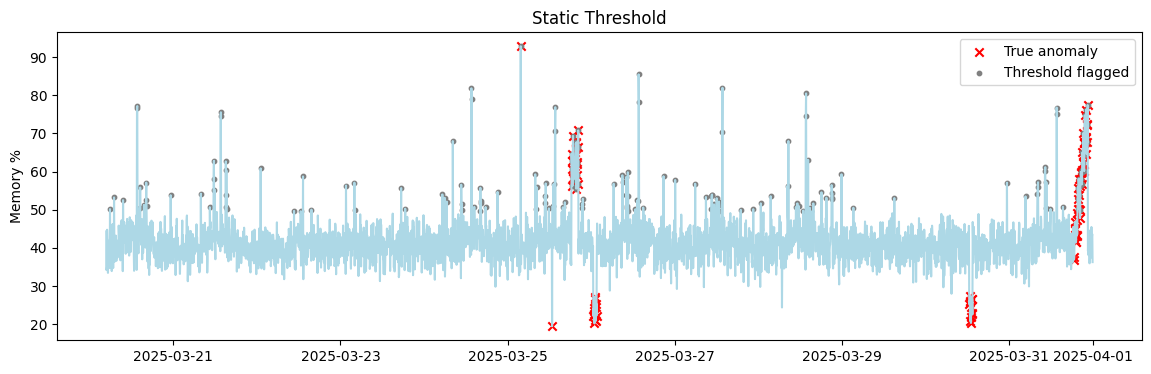

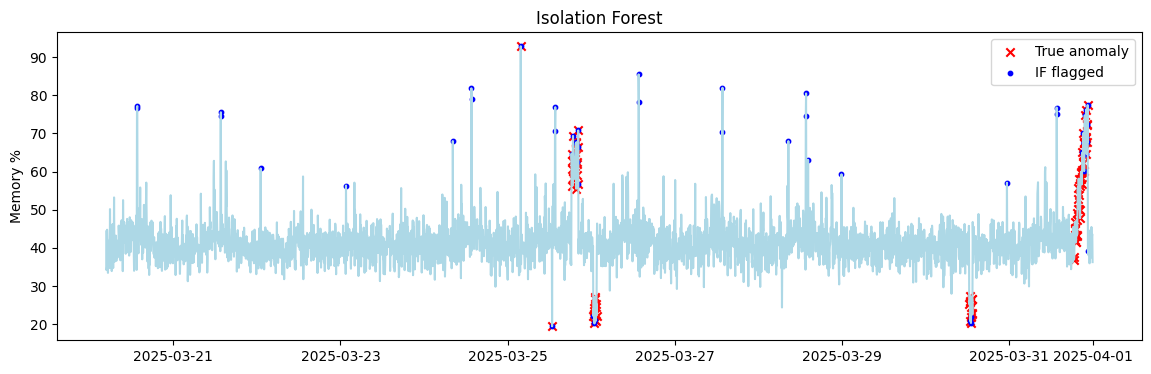

In [6]:
timestamps = test_data['timestamp'].values
memory = test_data['memory_pct'].values

plt.figure(figsize=(14, 4))
plt.plot(timestamps, memory, color='lightblue')
plt.scatter(timestamps[y_test == 1], memory[y_test == 1], color='red', marker='x', label='True anomaly')
plt.scatter(timestamps[threshold_predictions == 1], memory[threshold_predictions == 1], color='gray', s=10, label='Threshold flagged')
plt.title('Static Threshold')
plt.ylabel('Memory %')
plt.legend()
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(timestamps, memory, color='lightblue')
plt.scatter(timestamps[y_test == 1], memory[y_test == 1], color='red', marker='x', label='True anomaly')
plt.scatter(timestamps[isolation_predictions == 1], memory[isolation_predictions == 1], color='blue', s=10, label='IF flagged')
plt.title('Isolation Forest')
plt.ylabel('Memory %')
plt.legend()
plt.show()

## Evaluation metrics

In [7]:
print('=== Static Threshold ===')
print(classification_report(y_test, threshold_predictions, target_names=['Normal','Anomaly'], zero_division=0))
print('Confusion matrix:')
print(confusion_matrix(y_test, threshold_predictions))

print()
print('=== Isolation Forest ===')
print(classification_report(y_test, isolation_predictions, target_names=['Normal','Anomaly'], zero_division=0))
print('Confusion matrix:')
print(confusion_matrix(y_test, isolation_predictions))
print('ROC-AUC:', round(roc_auc_score(y_test, isolation_scores), 4))

=== Static Threshold ===
              precision    recall  f1-score   support

      Normal       0.99      0.96      0.97      3301
     Anomaly       0.30      0.60      0.40        98

    accuracy                           0.95      3399
   macro avg       0.65      0.78      0.69      3399
weighted avg       0.97      0.95      0.96      3399

Confusion matrix:
[[3166  135]
 [  39   59]]

=== Isolation Forest ===
              precision    recall  f1-score   support

      Normal       0.98      0.99      0.99      3301
     Anomaly       0.59      0.35      0.44        98

    accuracy                           0.97      3399
   macro avg       0.78      0.67      0.71      3399
weighted avg       0.97      0.97      0.97      3399

Confusion matrix:
[[3277   24]
 [  64   34]]
ROC-AUC: 0.897


## Statistical analysis using statsmodels

In [8]:
X_with_constant = sm.add_constant(X_train)
logit_model = sm.Logit(train_data['label'].values, X_with_constant)
logit_result = logit_model.fit()
print(logit_result.summary())

Optimization terminated successfully.
         Current function value: 0.029508
         Iterations 13
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                13593
Model:                          Logit   Df Residuals:                    13574
Method:                           MLE   Df Model:                           18
Date:                Thu, 21 May 2026   Pseudo R-squ.:                  0.5192
Time:                        22:16:19   Log-Likelihood:                -401.10
converged:                       True   LL-Null:                       -834.15
Covariance Type:            nonrobust   LLR p-value:                2.652e-172
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         36.3863     11.874      3.064      0.002      13.115      59.658
x1            -1.5665      0

In [9]:
print('Pseudo R-squared:', round(logit_result.prsquared, 4))
print('LLR p-value:', logit_result.llr_pvalue)
print('AIC:', round(logit_result.aic, 2))
print('BIC:', round(logit_result.bic, 2))

Pseudo R-squared: 0.5192
LLR p-value: 2.6524216142607783e-172
AIC: 840.2
BIC: 983.03
